In [3]:
import pandas as pd
import numpy as np

In [4]:
import scipy.stats as stats

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score

In [7]:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [15]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [14]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [16]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [17]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [18]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipykernel_246/694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [19]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [20]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

/tmp/ipykernel_246/4235241208.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


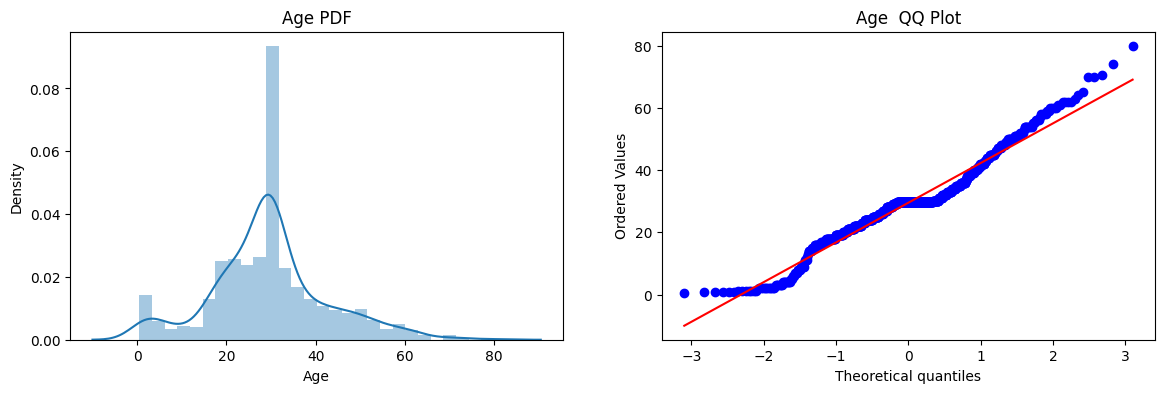

In [22]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'],dist= "norm", plot=plt)
plt.title('Age  QQ Plot')
plt.show()

/tmp/ipykernel_246/1277758265.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


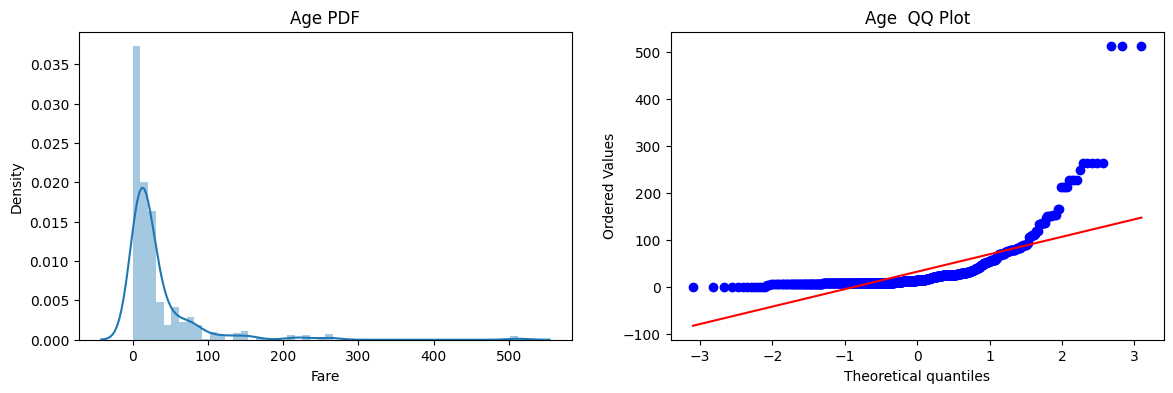

In [23]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'],dist= "norm", plot=plt)
plt.title('Age  QQ Plot')
plt.show()

In [24]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [25]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6927374301675978


In [26]:
trf = FunctionTransformer(func=np.log1p)

In [27]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)


In [28]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6871508379888268


In [29]:
X_transformed = trf.fit_transform(X)

clf  = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,cv=10,scoring='accuracy')))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,cv=10,scoring='accuracy')))


LR 0.678027465667915
DT 0.6610736579275904


Text(0.5, 1.0, 'Fare After log')

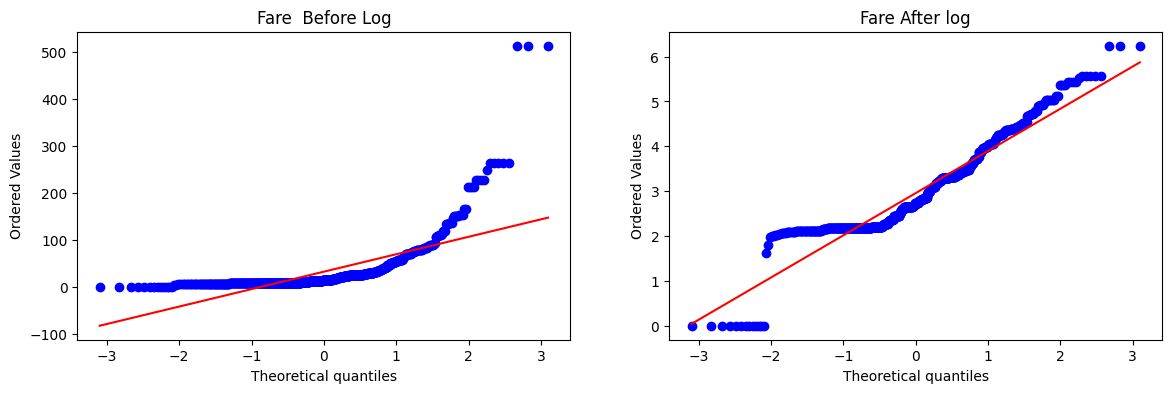

In [30]:
plt.figure  (figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'],dist= "norm", plot=plt)
plt.title('Fare  Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'],dist= "norm", plot=plt)
plt.title('Fare After log')

Text(0.5, 1.0, 'Age After log')

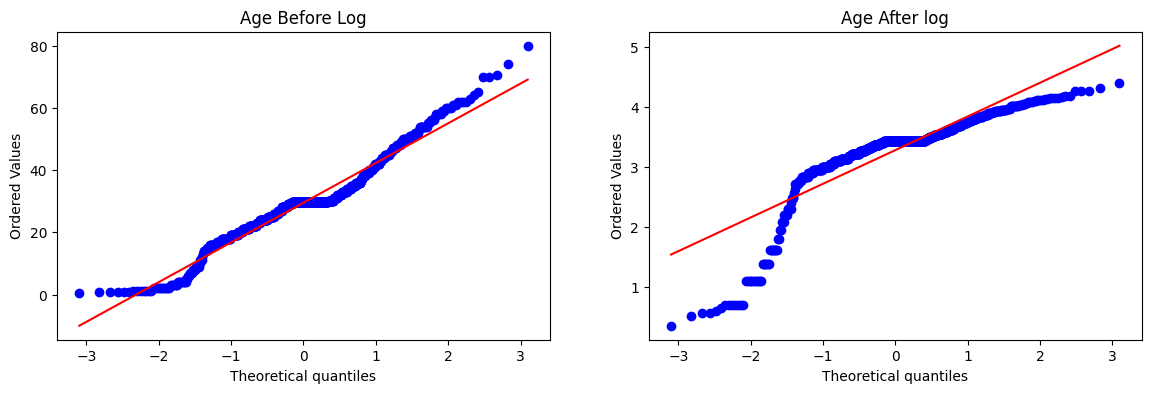

In [31]:
plt.figure  (figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'],dist= "norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'],dist= "norm", plot=plt)
plt.title('Age After log')

In [32]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [34]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6703910614525139


In [35]:
X_transformed2 = trf2.fit_transform(X)

clf  = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,cv=10,scoring='accuracy')))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,cv=10,scoring='accuracy')))


LR 0.6712609238451936
DT 0.6633458177278402


In [43]:
def apply_transform(transform):

    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('log', FunctionTransformer(transform), ['Fare'])],remainder='passthrough')

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accuracy",np.mean(cross_val_score(clf, X_trans, y, cv=10, scoring='accuracy')))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After transform')

    plt.show()



Accuracy 0.6589013732833957


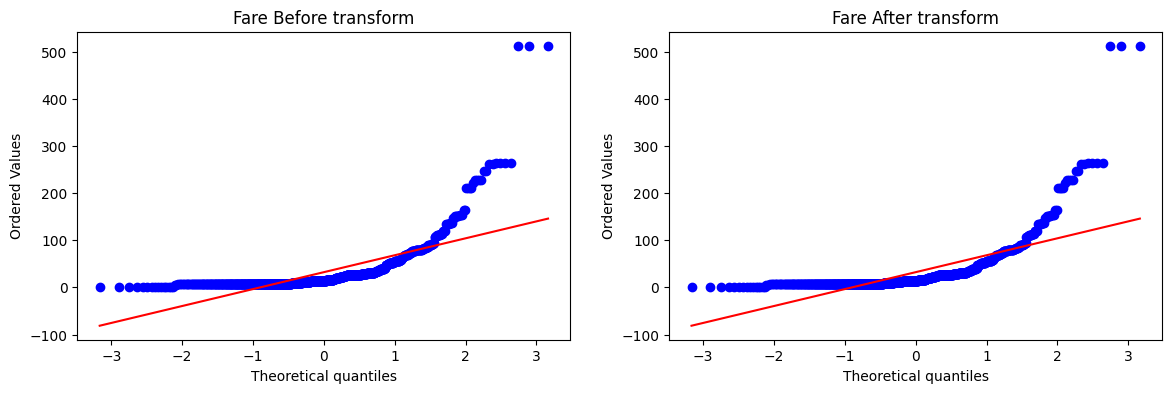

In [44]:
apply_transform(lambda x:x)

Accuracy 0.6431335830212235


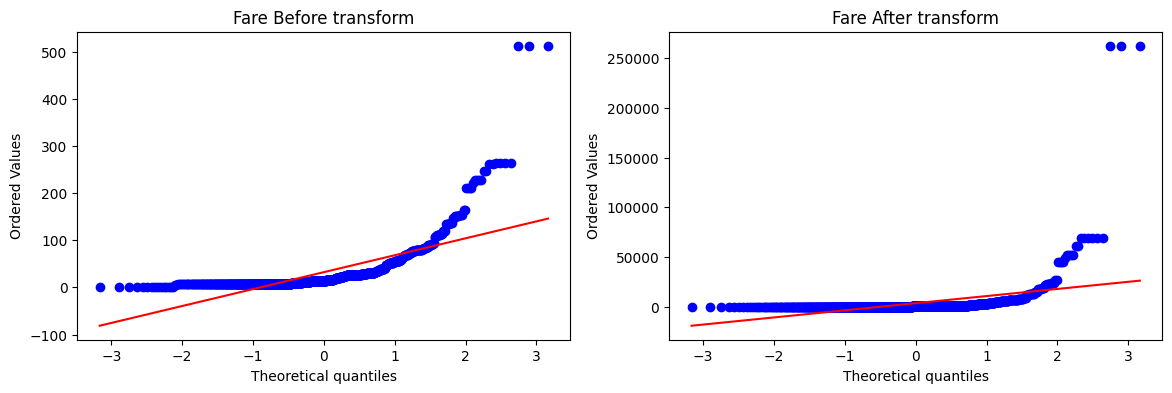

In [45]:
apply_transform(lambda x:x**2)

Accuracy 0.6589013732833957


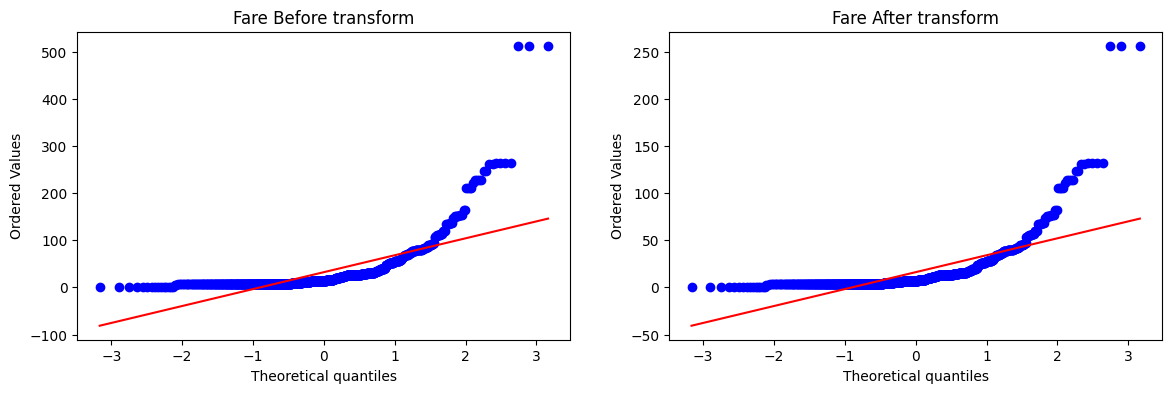

In [46]:
apply_transform(lambda x:x**1/2)

Accuracy 0.61729088639201


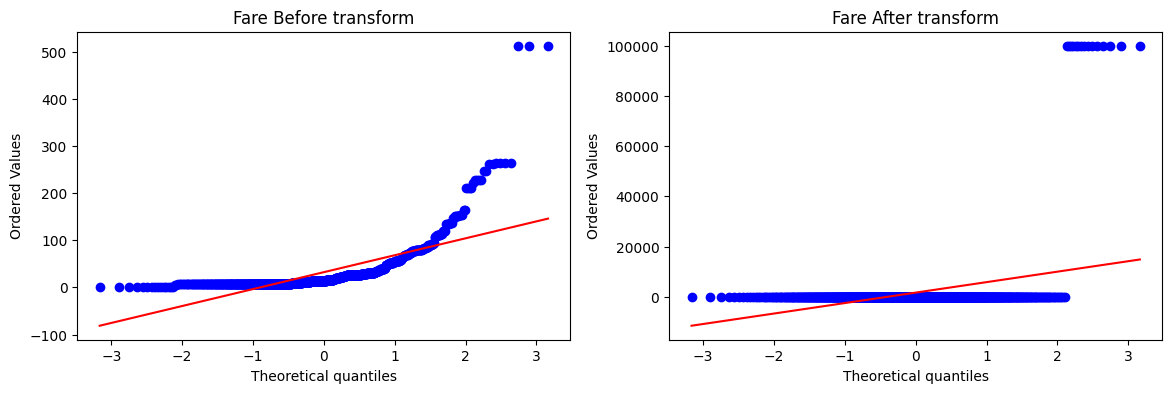

In [50]:
apply_transform(lambda x: 1/(x+0.00001))

Accuracy 0.6195131086142323


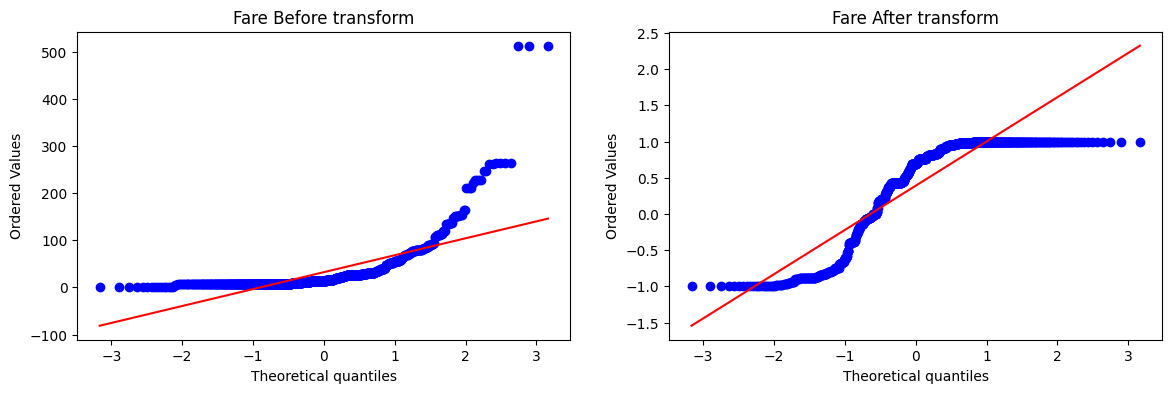

In [51]:
apply_transform(np.sin)